In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

## 1. Простая RNN с нуля (для понимания)

In [2]:
# ========== 1. Ручная реализация одного шага RNN ==========
def rnn_step_manual(x, h_prev, W_xh, W_hh, b_h):
    """
    x: (input_size) - вход на шаге t
    h_prev: (hidden_size) - предыдущее скрытое состояние
    W_xh: (hidden_size, input_size) - веса входа
    W_hh: (hidden_size, hidden_size) - веса рекуррентной связи
    b_h: (hidden_size) - смещение
    """
    h_next = torch.tanh(W_xh@x + W_hh@h_prev + b_h)
    return h_next



In [4]:
# Параметры
input_size = 3
hidden_size = 5

# Инициализируем веса
W_xh = torch.randn(hidden_size, input_size)
W_hh = torch.randn(hidden_size, hidden_size)
b_h = torch.randn(hidden_size)

# Создаем вход и состояние
x = torch.randn(input_size)
h_prev = torch.randn(hidden_size)

# Вычисляем
h_next = rnn_step_manual(x, h_prev, W_xh, W_hh, b_h)
print(f"Размер выхода: {h_next.shape}")  # torch.Size([5])
print(h_next)

Размер выхода: torch.Size([5])
tensor([ 0.9963, -0.9950,  0.9982,  0.5029,  0.6931])


## 2. Полная RNN с развертыванием во времени

In [7]:
# ========== 2. Развернутая RNN на последовательности ==========
def rnn_manual_forward(X, h0, W_xh, W_hh, b_h, W_hy, b_y):
    """
    X: (seq_len, batch_size, input_size)
    h0: (batch_size, hidden_size)
    """
    seq_len,batch_size,input_size = X.shape
    hidden_size = h0.shape[-1]

    h = h0  # (batch_size, hidden_size)
    outputs = []
    hidden_states = [h0]

    for t in range(seq_len):
        # Обрабатываем каждый шаг
        x_t = X[t]  # (batch_size, input_size)

        # Ручное обновление для всего batch
        h = torch.tanh(
            x_t @ W_xh.T +
            h @ W_hh.T +
            b_h
        )

        # Выходной слой
        y_t = h @ W_hy.T + b_y
        outputs.append(y_t)
        hidden_states.append(h)
    return torch.stack(outputs),torch.stack(hidden_states)


In [8]:
# Тестируем
seq_len, batch_size, input_size = 10, 4, 3
hidden_size, output_size = 5, 2

X = torch.randn(seq_len, batch_size, input_size)
h0 = torch.zeros(batch_size, hidden_size)

# Веса выходного слоя
W_hy = torch.randn(output_size, hidden_size)
b_y = torch.randn(output_size)

outputs, hidden_states = rnn_manual_forward(X, h0, W_xh, W_hh, b_h, W_hy, b_y)
print(f"Outputs shape: {outputs.shape}")  # torch.Size([10, 4, 2])
print(f"Hidden states shape: {hidden_states.shape}")  # torch.Size([11, 4, 5])

Outputs shape: torch.Size([10, 4, 2])
Hidden states shape: torch.Size([11, 4, 5])


In [9]:
outputs

tensor([[[-3.5390, -0.4993],
         [ 1.7195,  0.6327],
         [-2.4690, -1.5605],
         [-1.3567,  1.8254]],

        [[-2.9468, -1.5158],
         [ 0.3386, -0.2671],
         [ 1.0426,  0.3854],
         [-0.7922,  1.4577]],

        [[ 1.4944,  0.3561],
         [-0.8045, -0.6197],
         [ 1.6589,  0.5491],
         [ 0.0324, -0.6466]],

        [[-1.4827, -2.3400],
         [-0.4249, -0.5857],
         [-2.5807, -2.3471],
         [-1.3490,  1.6731]],

        [[ 1.8693,  1.5553],
         [ 1.9532, -0.1044],
         [-1.9404, -1.1448],
         [-2.7343, -1.6471]],

        [[-2.5997, -0.6232],
         [-2.6410, -0.6300],
         [-1.0755,  2.0306],
         [-2.1937, -1.4410]],

        [[-1.4041, -0.5230],
         [-0.8817,  0.6872],
         [-3.0444, -1.8462],
         [ 1.8775,  0.6405]],

        [[-4.7936, -3.2262],
         [ 0.7659,  0.6619],
         [-2.4945, -0.8513],
         [ 2.1209,  0.8247]],

        [[-2.8966, -1.0420],
         [ 0.6510,  1.9339]

## 3. Простая RNN через nn.RNN (встроенная)

In [10]:
# ========== 3. Использование встроенного nn.RNN ==========
class SimpleRNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=False,
            nonlinearity='tanh'
        )
        self.fc = nn.Linear(hidden_size,output_size)

    def forward(self,x,h0=None):
        # x: (seq_len, batch_size, input_size)
        out, h_n = self.rnn(x, h0)  # out: (seq_len, batch_size, hidden_size)
        out = self.fc(out)           # (seq_len, batch_size, output_size)
        return out, h_n
    

In [11]:
# Создаем модель
model = SimpleRNNModel(
    input_size=3,
    hidden_size=10,
    output_size=2,
    num_layers=2
)

X = torch.randn(20, 8, 3)  # 20 шагов, 8 примеров в батче
outputs, h_n = model(X)

print(f"Outputs: {outputs.shape}")  # torch.Size([20, 8, 2])
print(f"Last hidden: {h_n.shape}")  # torch.Size([2, 8, 10]) - (num_layers, batch, hidden)

Outputs: torch.Size([20, 8, 2])
Last hidden: torch.Size([2, 8, 10])


## 4. Проблема затухающих градиентов — демонстрация

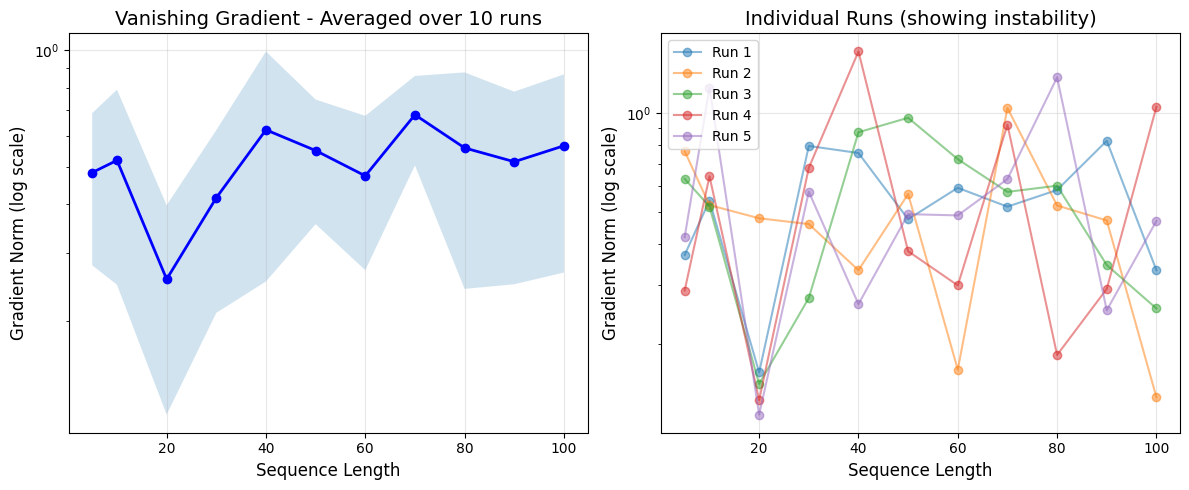


Итоговая статистика:
Длина 5:  средний градиент = 0.483074 ± 0.204905
Длина 100: средний градиент = 0.566652 ± 0.300332
Уменьшение в 0.85 раз


In [16]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

def stable_vanishing_gradient_demo(n_runs=10):
    """
    Усредняем по нескольким запускам, чтобы увидеть реальную тенденцию
    """
    seq_lengths = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    all_grad_norms = []
    
    for run in range(n_runs):
        run_grads = []
        for seq_len in seq_lengths:
            # Пересоздаем RNN для чистоты
            rnn = nn.RNN(
                input_size=1,
                hidden_size=10,
                num_layers=1,
                batch_first=False
            )
            
            X = torch.randn(seq_len, 1, 1)
            X.requires_grad_(True)
            
            # Forward
            out, _ = rnn(X)
            loss = out[-1].sum()
            
            # Backward
            loss.backward()
            
            # Норма градиента
            grad_norm = X.grad.norm().item()
            run_grads.append(grad_norm)
        
        all_grad_norms.append(run_grads)
    
    # Усредняем
    all_grad_norms = np.array(all_grad_norms)
    mean_grads = np.mean(all_grad_norms, axis=0)
    std_grads = np.std(all_grad_norms, axis=0)
    
    # Визуализация
    plt.figure(figsize=(12, 5))
    
    # График 1: средние значения
    plt.subplot(1, 2, 1)
    plt.plot(seq_lengths, mean_grads, 'bo-', linewidth=2, markersize=6)
    plt.fill_between(seq_lengths, 
                     mean_grads - std_grads, 
                     mean_grads + std_grads, 
                     alpha=0.2)
    plt.yscale('log')
    plt.xlabel('Sequence Length', fontsize=12)
    plt.ylabel('Gradient Norm (log scale)', fontsize=12)
    plt.title('Vanishing Gradient - Averaged over 10 runs', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # График 2: отдельные запуски
    plt.subplot(1, 2, 2)
    for i in range(min(5, n_runs)):
        plt.plot(seq_lengths, all_grad_norms[i], 'o-', alpha=0.5, label=f'Run {i+1}')
    plt.yscale('log')
    plt.xlabel('Sequence Length', fontsize=12)
    plt.ylabel('Gradient Norm (log scale)', fontsize=12)
    plt.title('Individual Runs (showing instability)', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nИтоговая статистика:")
    print(f"Длина 5:  средний градиент = {mean_grads[0]:.6f} ± {std_grads[0]:.6f}")
    print(f"Длина 100: средний градиент = {mean_grads[-1]:.6f} ± {std_grads[-1]:.6f}")
    print(f"Уменьшение в {mean_grads[0]/mean_grads[-1]:.2f} раз")

stable_vanishing_gradient_demo(n_runs=10)

In [17]:
def diagnose_gradient_problem():
    """
    Диагностика: затухание или взрыв?
    """
    rnn = nn.RNN(1, 5, 1, batch_first=False)
    
    # Проверяем спектральный радиус весов
    for name, param in rnn.named_parameters():
        if 'weight_hh' in name:  # рекуррентные веса
            W = param.detach()
            # Вычисляем сингулярные числа
            singular_values = torch.linalg.svd(W).S
            spectral_radius = singular_values.max().item()
            print(f"Спектральный радиус W_hh: {spectral_radius:.4f}")
            
            if spectral_radius > 1:
                print("⚠️  > 1 → градиенты будут ВЗРЫВАТЬСЯ!")
            elif spectral_radius < 1:
                print("✓ < 1 → градиенты будут ЗАТУХАТЬ")
            else:
                print("≈ 1 → стабильно, но редко")
    
    # Тест на длинной последовательности
    X_long = torch.randn(200, 1, 1)
    X_long.requires_grad_(True)
    
    out, _ = rnn(X_long)
    loss = out[-1].sum()
    loss.backward()
    
    grad_norm = X_long.grad.norm().item()
    print(f"\nГрадиент на длине 200: {grad_norm:.6f}")
    
    if grad_norm > 10:
        print("🚨 ВЗРЫВ ГРАДИЕНТА! (норма > 10)")
    elif grad_norm < 1e-6:
        print("⚠️ ЗАТУХАНИЕ ГРАДИЕНТА! (норма < 1e-6)")
    else:
        print("✓ Нормальный градиент")

diagnose_gradient_problem()

Спектральный радиус W_hh: 0.9282
✓ < 1 → градиенты будут ЗАТУХАТЬ

Градиент на длине 200: 0.942352
✓ Нормальный градиент


СПЕКТРАЛЬНЫЙ РАДИУС = 0.7 (затухание)

СПЕКТРАЛЬНЫЙ РАДИУС = 1.3 (взрыв)


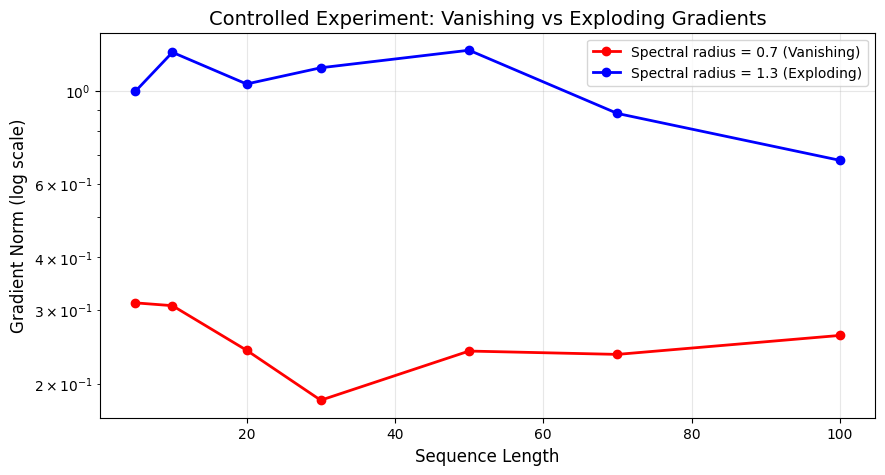


Затухание:  длина 5 → 0.3116, длина 100 → 0.2606
Уменьшение в 1 раз
Взрыв: длина 5 → 0.9954, длина 50 → 0.6816
Рост в 1 раз


In [18]:
def controlled_vanishing_demo():
    """
    Демонстрация с контролируемыми весами
    """
    class ControlledRNN(nn.Module):
        def __init__(self, spectral_radius=0.8):
            super().__init__()
            self.rnn = nn.RNN(1, 10, 1, batch_first=False)
            
            # Принудительно устанавливаем спектральный радиус
            with torch.no_grad():
                W_hh = self.rnn.weight_hh_l0
                # Нормализуем веса
                U, S, V = torch.svd(W_hh)
                S = S / S.max() * spectral_radius  # масштабируем
                W_hh_new = U @ torch.diag(S) @ V.T
                self.rnn.weight_hh_l0.copy_(W_hh_new)
        
        def forward(self, x):
            return self.rnn(x)
    
    seq_lengths = [5, 10, 20, 30, 50, 70, 100]
    
    # Случай 1: спектральный радиус < 1 (затухание)
    print("СПЕКТРАЛЬНЫЙ РАДИУС = 0.7 (затухание)")
    model_vanishing = ControlledRNN(spectral_radius=0.7)
    vanishing_grads = []
    
    for seq_len in seq_lengths:
        X = torch.randn(seq_len, 1, 1)
        X.requires_grad_(True)
        out, _ = model_vanishing.rnn(X)
        loss = out[-1].sum()
        loss.backward()
        vanishing_grads.append(X.grad.norm().item())
        X.grad = None
    
    # Случай 2: спектральный радиус > 1 (взрыв)
    print("\nСПЕКТРАЛЬНЫЙ РАДИУС = 1.3 (взрыв)")
    model_exploding = ControlledRNN(spectral_radius=1.3)
    exploding_grads = []
    
    for seq_len in seq_lengths[:7]:  # на больших длинах будет NaN
        X = torch.randn(seq_len, 1, 1)
        X.requires_grad_(True)
        out, _ = model_exploding.rnn(X)
        loss = out[-1].sum()
        loss.backward()
        exploding_grads.append(X.grad.norm().item())
        X.grad = None
    
    # Визуализация
    plt.figure(figsize=(10, 5))
    plt.plot(seq_lengths, vanishing_grads, 'ro-', label='Spectral radius = 0.7 (Vanishing)', linewidth=2)
    plt.plot(seq_lengths[:len(exploding_grads)], exploding_grads, 'bo-', label='Spectral radius = 1.3 (Exploding)', linewidth=2)
    plt.yscale('log')
    plt.xlabel('Sequence Length', fontsize=12)
    plt.ylabel('Gradient Norm (log scale)', fontsize=12)
    plt.title('Controlled Experiment: Vanishing vs Exploding Gradients', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"\nЗатухание:  длина 5 → {vanishing_grads[0]:.4f}, длина 100 → {vanishing_grads[-1]:.4f}")
    print(f"Уменьшение в {vanishing_grads[0]/vanishing_grads[-1]:.0f} раз")
    
    if len(exploding_grads) > 1:
        print(f"Взрыв: длина 5 → {exploding_grads[0]:.4f}, длина 50 → {exploding_grads[-1]:.4f}")
        print(f"Рост в {exploding_grads[-1]/exploding_grads[0]:.0f} раз")

controlled_vanishing_demo()

## 5 LSTM PyTorch реализация с нуля (для понимания)

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LSTMCellManual(nn.Module):
    """
    Ручная реализация одной ячейки LSTM
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        # Веса для всех 4 компонентов (forget, input, candidate, output)
        # Объединяем для эффективности
        self.W_f = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_i = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_c = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_o = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev, c_prev):
        """
        x: (batch, input_size)
        h_prev: (batch, hidden_size) - предыдущее скрытое состояние
        c_prev: (batch, hidden_size) - предыдущая ячейка памяти
        """
        # Конкатенируем вход и скрытое состояние
        combined = torch.cat([h_prev,x],dim=1)
        
        # 1. Forget gate
        f = torch.sigmoid(self.W_f(combined))

        # 2. Input gate
        i = torch.sigmoid(self.W_i(combined))

        # 3. Candidate memory
        c_tilde = torch.tanh(self.W_c(combined))
        
        # 4. Update cell memory
        c = f * c_prev + i * c_tilde

        # 5. Output gate
        o = torch.sigmoid(self.W_o(combined))

        # 6. Hidden state
        h = o * torch.tanh(c)

        return h,c

In [21]:
# Тестируем
lstm_cell = LSTMCellManual(input_size=10, hidden_size=20)
batch_size = 4
x = torch.randn(batch_size, 10)
h_prev = torch.zeros(batch_size, 20)
c_prev = torch.zeros(batch_size, 20)

h_next, c_next = lstm_cell(x, h_prev, c_prev)
print(f"h_next shape: {h_next.shape}")  # torch.Size([4, 20])
print(f"c_next shape: {c_next.shape}")  # torch.Size([4, 20])

h_next shape: torch.Size([4, 20])
c_next shape: torch.Size([4, 20])


In [22]:
# Простой LSTM
lstm = nn.LSTM(
    input_size=10,
    hidden_size=20,
    num_layers=2,      # 2 слоя LSTM друг над другом
    batch_first=False, # (seq, batch, features)
    dropout=0.2,       # dropout между слоями
    bidirectional=False
)

x = torch.randn(15, 4, 10)
output, (h_n, c_n) = lstm(x)

print(f"Output: {output.shape}")      # (15, 4, 20)
print(f"Hidden: {h_n.shape}")         # (2, 4, 20) - (num_layers, batch, hidden)
print(f"Cell state: {c_n.shape}")     # (2, 4, 20)

Output: torch.Size([15, 4, 20])
Hidden: torch.Size([2, 4, 20])
Cell state: torch.Size([2, 4, 20])


## 6 GRU PyTorch реализация с нуля

In [24]:
class GRUCellManual(nn.Module):
    """
    Ручная реализация GRU ячейки
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        # Reset gate
        self.W_r = nn.Linear(input_size + hidden_size, hidden_size)
        # Update gate
        self.W_z = nn.Linear(input_size + hidden_size, hidden_size)
        # Candidate hidden state
        self.W_h = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev):
        """
        x: (batch, input_size)
        h_prev: (batch, hidden_size)
        """
        # Конкатенируем вход и прошлое состояние
        combined = torch.cat([h_prev, x], dim=1)  # (batch, hidden+input)

        # 1. Reset gate
        r = torch.sigmoid(self.W_r(combined))  # (batch, hidden)
        
        # 2. Update gate
        z = torch.sigmoid(self.W_z(combined))  # (batch, hidden)
        
        # 3. Candidate (применяем reset к прошлому состоянию)
        # r ⊙ h_prev — поэлементное умножение
        reset_hidden = r * h_prev
        combined_reset = torch.cat([reset_hidden,x],dim=1)
        h_tilde = torch.tanh(self.W_h(combined_reset))

        # 4. Final hidden (линейная интерполяция)
        h = (1 - z) * h_tilde + z * h_prev
        
        return h

In [26]:
gru_cell = GRUCellManual(input_size=10, hidden_size=20)
batch_size = 4
x = torch.randn(batch_size, 10)
h_prev = torch.zeros(batch_size, 20)

h_next = gru_cell(x, h_prev)
print(f"h_next shape: {h_next.shape}")  # torch.Size([4, 20])

h_next shape: torch.Size([4, 20])
